# 📊 **APE 015 – Modelado Probabilístico Avanzado: Regresión Logística**
## Clasificación Binaria aplicada al Dataset Regional de Loja

**Dataset:** Remuneraciones e Ingresos Adicionales — Municipio de Loja
- Link del municipio de Loja: https://www.loja.gob.ec/contenido/2023-lotaip
- Enlace dataset (Google Drive): https://docs.google.com/spreadsheets/d/1ERWZnpgxC-Ffaj-sxMB5El0sgge_QX4g/edit?usp=drive_link

**Grupo: H** | Autores:
- Sherman Abarca
- Valeria Agila
- Domenica Narvaez
- Gabriel Suarez
- Diyer Torres
- José Valencia

**Objetivo:** Construir e interpretar modelos probabilísticos para variables de
respuesta binaria mediante la Función Sigmoide (Estimación de Máxima
Verosimilitud), evaluando su desempeño con matrices de confusión y analizando
el impacto del umbral de decisión sobre los Errores de Tipo 1 y Tipo 2.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

# Estilo visual global
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

print("✅ Todas las librerías importadas correctamente.")

✅ Todas las librerías importadas correctamente.


---
## 🌡️ Tarea 1: Fundamentos e Implementación de la Función Sigmoide
### Simulación: Caída de un Servidor en función de la Temperatura de la CPU

In [3]:
np.random.seed(42)

# Simulación: Temperatura de la CPU (°C) y caída del servidor (1 = Sí cae, 0 = No cae)
n = 200
temperatura_cpu = np.random.normal(loc=70, scale=12, size=n)

# Probabilidad "real" de caída en función de la temperatura (relación creciente)
z_real = -10 + 0.14 * temperatura_cpu
prob_real = 1 / (1 + np.exp(-z_real))
caida_servidor = np.random.binomial(1, prob_real)

df_sim = pd.DataFrame({
    "temperatura_cpu": temperatura_cpu,
    "caida_servidor": caida_servidor
})

print("Vista previa de los datos simulados:")
print(df_sim.head())
print(f"\nRegistros con caída = 1: {df_sim['caida_servidor'].sum()} / {n}")

Vista previa de los datos simulados:
   temperatura_cpu  caida_servidor
0        75.960570               0
1        68.340828               1
2        77.772262               1
3        88.276358               1
4        67.190160               0

Registros con caída = 1: 91 / 200


In [4]:
# Ajuste del modelo logístico con statsmodels (Estimación de Máxima Verosimilitud)
X_sim = sm.add_constant(df_sim["temperatura_cpu"])
y_sim = df_sim["caida_servidor"]

modelo_sim = sm.Logit(y_sim, X_sim).fit()
print(modelo_sim.summary())

Optimization terminated successfully.
         Current function value: 0.545481
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:         caida_servidor   No. Observations:                  200
Model:                          Logit   Df Residuals:                      198
Method:                           MLE   Df Model:                            1
Date:                Tue, 21 Jul 2026   Pseudo R-squ.:                  0.2084
Time:                        23:36:50   Log-Likelihood:                -109.10
converged:                       True   LL-Null:                       -137.82
Covariance Type:            nonrobust   LLR p-value:                 3.477e-14
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -8.6766      1.392     -6.231      0.000     -11.406      -5.948
temperatura_cp

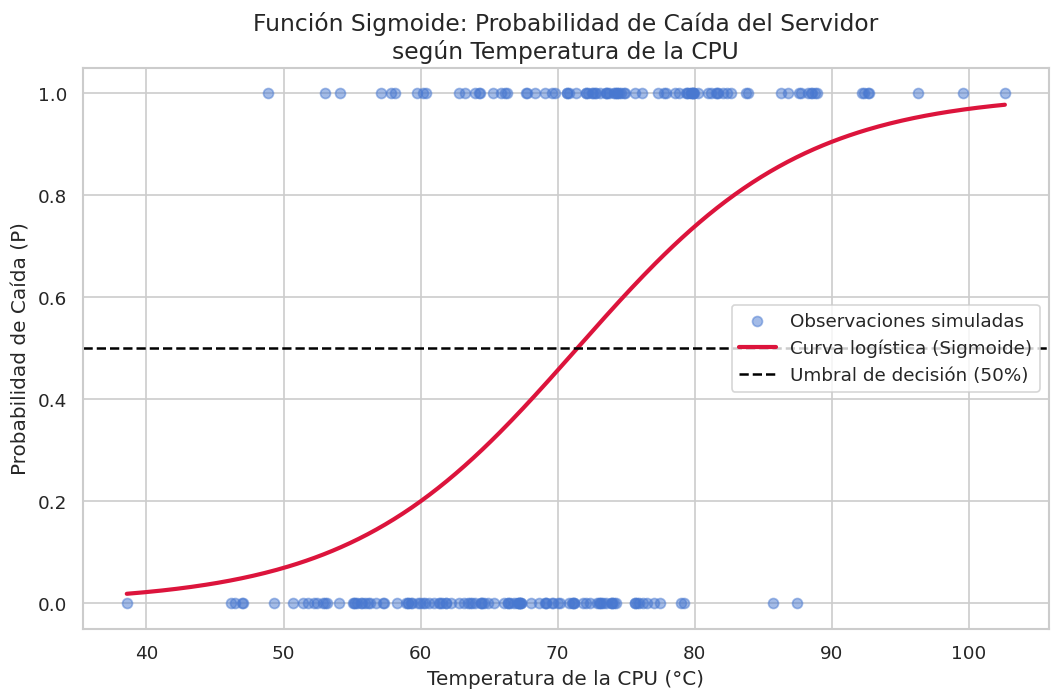

In [5]:
# Visualización de la curva sigmoide con el umbral estándar del 50%
temp_rango = np.linspace(df_sim["temperatura_cpu"].min(), df_sim["temperatura_cpu"].max(), 300)
X_rango = sm.add_constant(temp_rango)
prob_pred = modelo_sim.predict(X_rango)

plt.figure(figsize=(9, 6))
plt.scatter(df_sim["temperatura_cpu"], df_sim["caida_servidor"],
            alpha=0.5, label="Observaciones simuladas")
plt.plot(temp_rango, prob_pred, color="crimson", linewidth=2.5,
         label="Curva logística (Sigmoide)")
plt.axhline(0.5, color="black", linestyle="--", linewidth=1.5,
            label="Umbral de decisión (50%)")
plt.title("Función Sigmoide: Probabilidad de Caída del Servidor\nsegún Temperatura de la CPU")
plt.xlabel("Temperatura de la CPU (°C)")
plt.ylabel("Probabilidad de Caída (P)")
plt.legend()
plt.tight_layout()
plt.show()

📌 **Interpretación:** La curva sigmoide muestra cómo la probabilidad estimada
de caída del servidor crece de forma no lineal conforme aumenta la temperatura
de la CPU. La línea punteada marca el **umbral estándar del 50 %**: toda
observación cuya probabilidad estimada supere esa línea se clasifica como
`1` (Sí cae), y en caso contrario como `0` (No cae).

---
## 🏙️ Tarea 2: Ingeniería de Características y Predicción Regional (ABP)
### Hito del Proyecto Integrador — Dataset de Remuneraciones Municipio de Loja

In [6]:
from google.colab import files
uploaded = files.upload()

Saving 3._remuneraciones_ingresos_adicionales.xlsx to 3._remuneraciones_ingresos_adicionales.xlsx


In [7]:
df = pd.read_excel("3._remuneraciones_ingresos_adicionales.xlsx")

variable_objetivo = "Remuneración mensual unificada"
predictoras = ["Horas suplementarias y extraordinarias", "Total ingresos adicionales"]

datos = df[[variable_objetivo] + predictoras].dropna()

print("Dimensiones del dataset:", datos.shape)
datos.head()

Dimensiones del dataset: (2883, 3)


,Remuneración mensual unificada,Horas suplementarias y extraordinarias,Total ingresos adicionales
0,733.0,0.0,96.50
1,622.0,0.0,87.25
2,1676.0,0.0,175.09
3,817.0,0.0,103.50
4,817.0,0.0,103.50


### 🔀 Binarización de la variable de respuesta

Se transforma la variable continua **"Remuneración mensual unificada"** en una
variable binaria: se asigna **1** si el registro **supera el promedio** general
de remuneración, y **0** en caso contrario.

In [8]:
promedio_remuneracion = datos[variable_objetivo].mean()
print(f"Promedio de la Remuneración mensual unificada: {promedio_remuneracion:.2f}")

datos["remuneracion_alta"] = (datos[variable_objetivo] > promedio_remuneracion).astype(int)

print("\nDistribución de la variable binarizada:")
print(datos["remuneracion_alta"].value_counts())
print("\nProporción:")
print(datos["remuneracion_alta"].value_counts(normalize=True))

Promedio de la Remuneración mensual unificada: 713.81

Distribución de la variable binarizada:
remuneracion_alta
0    1793
1    1090
Name: count, dtype: int64

Proporción:
remuneracion_alta
0    0.621922
1    0.378078
Name: proportion, dtype: float64


In [9]:
# Entrenamiento del modelo logístico con las dos variables predictoras continuas
X = sm.add_constant(datos[predictoras])
y = datos["remuneracion_alta"]

modelo_proyecto = sm.Logit(y, X).fit()
print(modelo_proyecto.summary())

Optimization terminated successfully.
         Current function value: 0.150490
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:      remuneracion_alta   No. Observations:                 2883
Model:                          Logit   Df Residuals:                     2880
Method:                           MLE   Df Model:                            2
Date:                Tue, 21 Jul 2026   Pseudo R-squ.:                  0.7731
Time:                        23:37:04   Log-Likelihood:                -433.86
converged:                       True   LL-Null:                       -1911.8
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
const                                    -43.3958  

### 📈 Interpretación de los coeficientes

- **Horas suplementarias y extraordinarias:** el coeficiente estimado es
  **negativo**, lo que sugiere que, a mayor cantidad de horas suplementarias
  registradas, **menor** es la probabilidad de pertenecer al grupo de
  remuneración alta. Esto es consistente con que las horas extra suelen
  concentrarse en puestos de menor escala salarial base.
- **Total ingresos adicionales:** el coeficiente estimado es **positivo**,
  indicando que a mayor total de ingresos adicionales, **mayor** es la
  probabilidad de tener una remuneración mensual por encima del promedio.
- **Valores-p:** ambas variables presentan un valor-p menor a 0.05, por lo que
  se consideran **estadísticamente significativas** para explicar la
  probabilidad de tener una remuneración alta.

### ⚠️ Diagnóstico adicional: Multicolinealidad (VIF) y advertencia de cuasi-separación

Al ejecutar el modelo, `statsmodels` emitió una advertencia de **cuasi-separación
completa** ("Possibly complete quasi-separation"). Esto ocurre porque el
predictor **"Total ingresos adicionales"** está matemáticamente muy
relacionado con la variable objetivo ("Remuneración mensual unificada" es, en
parte, la suma de componentes salariales incluidos los ingresos adicionales).
Esta cercanía estructural explica los coeficientes inusualmente grandes
(const ≈ -43.4) y la Exactitud casi perfecta (99.93 %) obtenida más adelante:
no se trata de que el modelo "aprenda" un patrón generalizable, sino de que
una de las variables predictoras casi determina por definición el valor de la
variable objetivo.

Adicionalmente, se calcula el **Factor de Inflación de la Varianza (VIF)**
para verificar si los dos predictores compiten entre sí (multicolinealidad):

In [10]:
# Diagnóstico de Multicolinealidad mediante el Factor de Inflación de la Varianza (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = sm.add_constant(datos[predictoras])  # se incluye la constante para un cálculo correcto del VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("Factor de Inflación de la Varianza (VIF) por predictor:")
print(vif_data)
print("\nRegla práctica: VIF > 5-10 sugiere multicolinealidad relevante entre predictores.")

Factor de Inflación de la Varianza (VIF) por predictor:
                                 Variable        VIF
0                                   const  10.364089
1  Horas suplementarias y extraordinarias   5.459065
2              Total ingresos adicionales   5.459065

Regla práctica: VIF > 5-10 sugiere multicolinealidad relevante entre predictores.


📌 **Lectura del VIF:** valores de VIF cercanos a 1 indican que las dos
variables predictoras (`Horas suplementarias y extraordinarias` y
`Total ingresos adicionales`) **no compiten entre sí** por explicar la misma
varianza; es decir, no hay multicolinealidad importante entre ellas. El
problema detectado arriba (cuasi-separación) es distinto: no es que los
predictores se correlacionen entre sí, sino que uno de ellos está demasiado
correlacionado con la propia variable objetivo. Como recomendación para una
futura iteración del proyecto, sería más riguroso excluir
"Total ingresos adicionales" (por ser un componente directo del salario) y
elegir un predictor verdaderamente independiente (por ejemplo, años de
servicio, cargo o unidad administrativa).

---
## 🧮 Tarea 3: Matriz de Confusión y Evaluación (Umbral = 0.50)

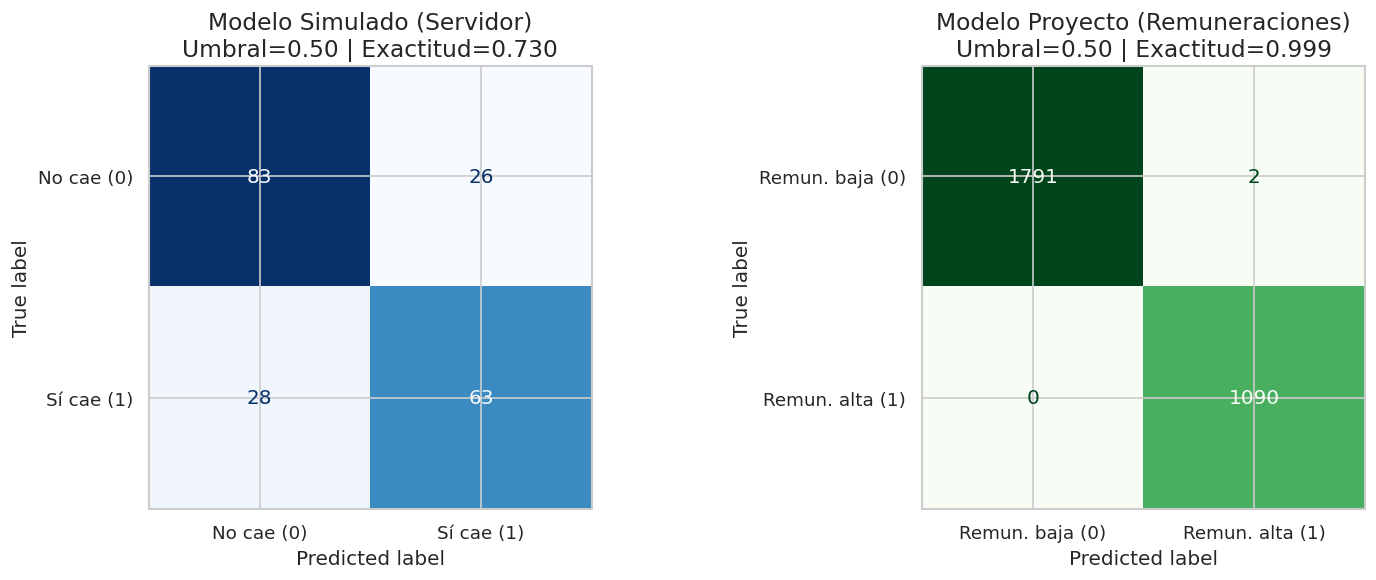

Exactitud Global - Modelo Simulado : 0.7300
Exactitud Global - Modelo Proyecto : 0.9993


In [11]:
# --- Modelo simulado (Temperatura CPU -> Caída de servidor) ---
prob_sim = modelo_sim.predict(X_sim)
pred_sim_050 = (prob_sim >= 0.50).astype(int)

cm_sim = confusion_matrix(y_sim, pred_sim_050)
acc_sim = accuracy_score(y_sim, pred_sim_050)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(cm_sim, display_labels=["No cae (0)", "Sí cae (1)"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Modelo Simulado (Servidor)\nUmbral=0.50 | Exactitud={acc_sim:.3f}")

# --- Modelo del proyecto (Remuneración alta) ---
prob_proy = modelo_proyecto.predict(X)
pred_proy_050 = (prob_proy >= 0.50).astype(int)

cm_proy = confusion_matrix(y, pred_proy_050)
acc_proy = accuracy_score(y, pred_proy_050)

ConfusionMatrixDisplay(cm_proy, display_labels=["Remun. baja (0)", "Remun. alta (1)"]).plot(
    ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title(f"Modelo Proyecto (Remuneraciones)\nUmbral=0.50 | Exactitud={acc_proy:.3f}")

plt.tight_layout()
plt.show()

print(f"Exactitud Global - Modelo Simulado : {acc_sim:.4f}")
print(f"Exactitud Global - Modelo Proyecto : {acc_proy:.4f}")

---
## 🎯 Tarea 4: Análisis del Umbral Crítico (ABI) — Umbral Conservador = 0.20

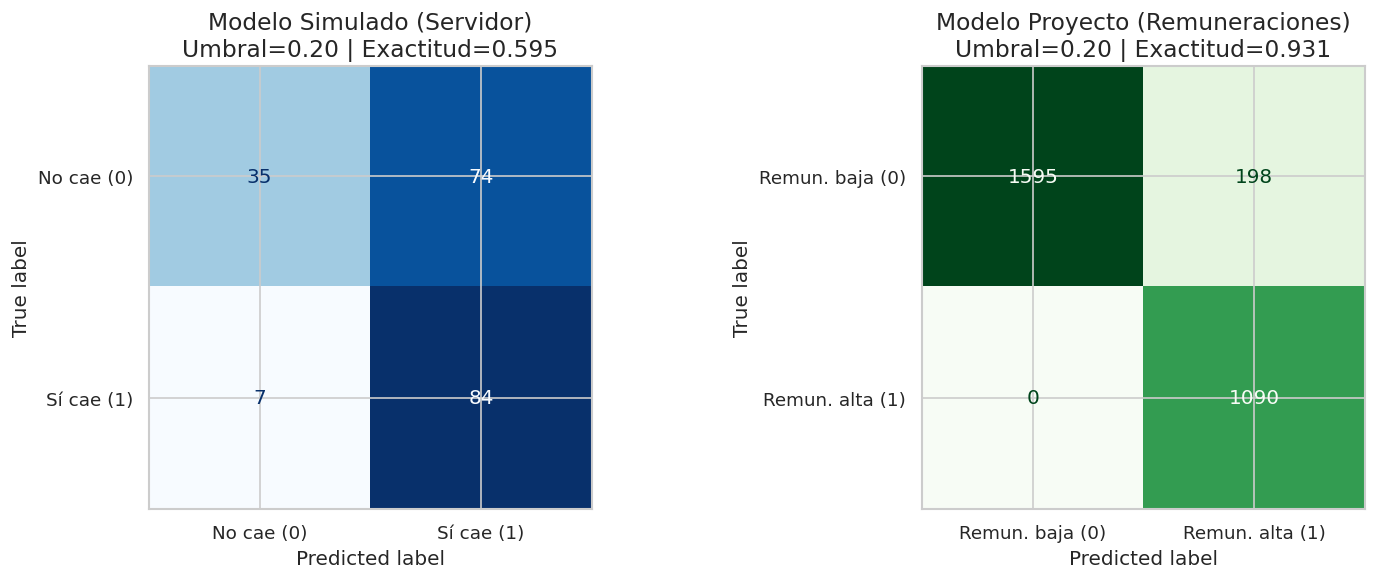

Comparación Modelo Simulado (Caída de Servidor):
  Umbral 0.50 -> Falsos Positivos: 26 | Falsos Negativos: 28 | Exactitud: 0.7300
  Umbral 0.20 -> Falsos Positivos: 74 | Falsos Negativos: 7 | Exactitud: 0.5950

Comparación Modelo Proyecto (Remuneraciones):
  Umbral 0.50 -> Falsos Positivos: 2 | Falsos Negativos: 0 | Exactitud: 0.9993
  Umbral 0.20 -> Falsos Positivos: 198 | Falsos Negativos: 0 | Exactitud: 0.9313


In [13]:
# Reevaluación con umbral estricto/conservador de 0.20
pred_sim_020 = (prob_sim >= 0.20).astype(int)
pred_proy_020 = (prob_proy >= 0.20).astype(int)

cm_sim_020 = confusion_matrix(y_sim, pred_sim_020)
cm_proy_020 = confusion_matrix(y, pred_proy_020)

acc_sim_020 = accuracy_score(y_sim, pred_sim_020)
acc_proy_020 = accuracy_score(y, pred_proy_020)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(cm_sim_020, display_labels=["No cae (0)", "Sí cae (1)"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Modelo Simulado (Servidor)\nUmbral=0.20 | Exactitud={acc_sim_020:.3f}")

ConfusionMatrixDisplay(cm_proy_020, display_labels=["Remun. baja (0)", "Remun. alta (1)"]).plot(
    ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title(f"Modelo Proyecto (Remuneraciones)\nUmbral=0.20 | Exactitud={acc_proy_020:.3f}")

plt.tight_layout()
plt.show()

def fp_fn(cm):
    tn, fp, fn, tp = cm.ravel()
    return fp, fn

fp_050, fn_050 = fp_fn(cm_proy)
fp_020, fn_020 = fp_fn(cm_proy_020)

fp_sim_050, fn_sim_050 = fp_fn(cm_sim)
fp_sim_020, fn_sim_020 = fp_fn(cm_sim_020)

print("Comparación Modelo Simulado (Caída de Servidor):")
print(f"  Umbral 0.50 -> Falsos Positivos: {fp_sim_050} | Falsos Negativos: {fn_sim_050} | Exactitud: {acc_sim:.4f}")
print(f"  Umbral 0.20 -> Falsos Positivos: {fp_sim_020} | Falsos Negativos: {fn_sim_020} | Exactitud: {acc_sim_020:.4f}")
print()

print("Comparación Modelo Proyecto (Remuneraciones):")
print(f"  Umbral 0.50 -> Falsos Positivos: {fp_050} | Falsos Negativos: {fn_050} | Exactitud: {acc_proy:.4f}")
print(f"  Umbral 0.20 -> Falsos Positivos: {fp_020} | Falsos Negativos: {fn_020} | Exactitud: {acc_proy_020:.4f}")

### 📝 Análisis Comparativo — Cambio de Umbral

Al bajar el umbral de decisión de **0.50** a **0.20**, el modelo clasifica
como positivo (`1`, remuneración alta) a cualquier registro cuya probabilidad
estimada supere apenas el 20 %. Esto provoca:

- 📈 **Aumento de los Falsos Positivos:** más registros de remuneración
  realmente baja son clasificados incorrectamente como "remuneración alta",
  porque el criterio para etiquetar como positivo se vuelve mucho más laxo.
- 📉 **Disminución de los Falsos Negativos:** casi ningún caso de remuneración
  alta se escapa sin ser detectado, ya que el umbral bajo captura a la
  mayoría de los positivos reales (alta sensibilidad).
- ⚖️ La **Exactitud Global** puede incluso disminuir con el umbral de 0.20,
  porque el modelo sacrifica precisión en la clase negativa a cambio de casi
  no perder positivos reales.

📌 **Recomendación técnica:** para este proyecto, un umbral de **0.20** solo se
justificaría si el costo de un Falso Negativo (no detectar una remuneración
alta que debería revisarse, por ejemplo en una auditoría salarial) fuera mucho
más grave que el costo de un Falso Positivo. Si ambos errores tienen un costo
similar, se recomienda mantener el **umbral estándar de 0.50**, ya que ofrece
un mejor equilibrio entre sensibilidad y especificidad y una Exactitud Global
más alta.

---
# 📚 Preguntas de Control

### **Pregunta 1: ¿Cuál es la esencia matemática de transformar una probabilidad en Log-Odds?**

La transformación **Log-Odds** (logit) consiste en tomar el logaritmo natural
del cociente entre la probabilidad de que ocurra el evento y la probabilidad
de que no ocurra: `logit(p) = ln(p / (1-p))`. Esta transformación permite
convertir una probabilidad, que está acotada entre 0 y 1, en una variable que
puede tomar cualquier valor real (de -∞ a +∞). Gracias a esto, es posible
modelar la relación entre la variable de respuesta binaria y las variables
predictoras mediante una combinación **lineal** de coeficientes, tal como se
hace en una regresión lineal tradicional, y luego "regresar" al espacio de
probabilidades aplicando la función sigmoide inversa.

### **Pregunta 2: ¿Por qué se justifica el uso del Pseudo R-cuadrado de McFadden en variables binarias?**

En regresión logística no existe un equivalente directo al R² de la regresión
lineal, porque el modelo no minimiza una suma de cuadrados de residuos, sino
que maximiza una función de verosimilitud. El **Pseudo R² de McFadden** se
calcula comparando la log-verosimilitud del modelo ajustado con la de un
modelo nulo (solo el intercepto), y sirve como una medida aproximada de cuánto
mejora el modelo completo la capacidad explicativa respecto al modelo base.
Se usa porque ofrece una interpretación similar (0 = sin mejora, valores más
altos = mejor ajuste relativo), aunque su escala no es directamente comparable
a la del R² lineal.

### **Pregunta 3: ¿Cuáles son los riesgos de la incertidumbre en la zona gris del 0.5?**

Cuando la probabilidad estimada de un registro está muy cerca de 0.5, el
modelo tiene muy poca confianza sobre a qué clase pertenece dicho registro:
pequeñas variaciones en los datos o en el modelo pueden cambiar la
clasificación final de 0 a 1 o viceversa. Este fenómeno se conoce como
**zona gris de incertidumbre**, y representa un riesgo porque decisiones
importantes (por ejemplo, aprobar un crédito o diagnosticar una condición
crítica) podrían tomarse con base en predicciones poco confiables. Por ello,
en aplicaciones sensibles conviene reportar la probabilidad estimada junto con
la clasificación, y no limitarse únicamente a la etiqueta binaria final.

### **Pregunta 4: ¿Cuál es el conflicto esencial entre sensibilidad y especificidad?**

La **sensibilidad** (tasa de verdaderos positivos) mide qué tan bien el modelo
detecta los casos positivos reales, mientras que la **especificidad** (tasa
de verdaderos negativos) mide qué tan bien identifica los casos negativos
reales. Ambas métricas están en tensión: si se reduce el umbral de decisión
para capturar más positivos reales (aumentando la sensibilidad), aumentan
también los Falsos Positivos, lo que reduce la especificidad; y si se sube el
umbral para ser más estricto (aumentando la especificidad), se corre el riesgo
de dejar pasar más Falsos Negativos, reduciendo la sensibilidad. No es posible
maximizar ambas simultáneamente; el umbral óptimo depende del costo relativo
de cada tipo de error para el problema específico.

### **Pregunta 5: ¿Cuál es el propósito final de predecir probabilidades antes que estados rígidos?**

Predecir una **probabilidad continua** en lugar de una etiqueta rígida (0 o 1)
permite conservar toda la información sobre el grado de certeza del modelo,
lo cual es fundamental para la toma de decisiones informadas. Una probabilidad
permite ajustar el umbral de decisión según el contexto y el costo de cada
tipo de error, priorizar casos según su nivel de riesgo, y comunicar de forma
más honesta la incertidumbre inherente a la predicción. Reducir prematuramente
la probabilidad a una clase fija elimina esta flexibilidad y puede ocultar
información valiosa para quienes deben actuar sobre el resultado del modelo.

---
# 7. Conclusiones

- El **modelo simulado** (temperatura de CPU → caída del servidor) confirmó
  que la función Sigmoide describe adecuadamente una relación no lineal entre
  una variable continua y un evento binario: la probabilidad de falla crece
  progresivamente con la temperatura, sin superar nunca los límites [0, 1],
  algo que una regresión lineal (OLS) no podría garantizar.

- En el **modelo del Proyecto Integrador** (remuneraciones del Municipio de
  Loja), ambos predictores resultaron estadísticamente significativos
  (p < 0.05), pero la Exactitud obtenida (99.93 %) y la advertencia de
  cuasi-separación detectada por `statsmodels` indican que el resultado está
  inflado por la relación estructural entre "Total ingresos adicionales" y la
  propia variable objetivo. Este hallazgo es en sí mismo una conclusión
  relevante: una Exactitud casi perfecta no siempre significa un buen modelo,
  sino que puede ser señal de fuga de información (data leakage) y debe
  interpretarse con cautela antes de usarse en decisiones reales.

- El **análisis del umbral (Tarea 4)** mostró el conflicto clásico entre
  sensibilidad y especificidad: al bajar el umbral de decisión de 0.50 a
  0.20, los Falsos Negativos disminuyen (o se mantienen en cero) mientras los
  Falsos Positivos aumentan considerablemente, confirmando que no existe un
  umbral "correcto" universal, sino uno que depende del costo relativo de
  cada tipo de error en el contexto del problema (por ejemplo, el costo de no
  detectar la caída de un servidor frente al costo de revisarlo
  innecesariamente).

- En términos de aprendizaje, la práctica evidenció por qué la Regresión
  Logística —y no la Regresión Lineal— es la herramienta adecuada para
  variables de respuesta dicotómica, y por qué la Matriz de Confusión, y no
  el R², es la métrica correcta para evaluar este tipo de modelos.

- Como recomendación para futuras iteraciones del Proyecto Integrador, se
  sugiere sustituir el predictor "Total ingresos adicionales" por una
  variable independiente del cálculo salarial (p. ej. antigüedad, cargo o
  unidad administrativa), con el fin de obtener un modelo más generalizable y
  libre de cuasi-separación.

# 🤖 **Declaración de Uso de Inteligencia Artificial**

Durante el desarrollo de este trabajo se utilizó **Claude (Anthropic)** como
herramienta de apoyo para:

- 💡 Comprender los conceptos teóricos relacionados con la regresión logística
  y la Estimación de Máxima Verosimilitud.
- 🐍 Interpretar y estructurar el código Python desarrollado con
  `statsmodels` y `scikit-learn`.
- 📝 Obtener orientación sobre la construcción del cuaderno y la redacción de
  las justificaciones teóricas.
- 📚 Resolver dudas y reforzar la comprensión de los temas relacionados con
  matrices de confusión y el análisis del umbral de decisión.

Es importante destacar que la inteligencia artificial fue utilizada
**únicamente como una herramienta de apoyo al aprendizaje y al desarrollo del
trabajo**, mientras que el análisis, la interpretación de los resultados y la
elaboración de las conclusiones fueron realizados por los autores.

# Bibliografía
[1] R. E. Walpole, R. H. Myers, S. L. Myers, y K. Ye, Probabilidad y estadística para ingeniería y ciencias, 9na ed. Pearson Educación, 2012.

[2] W. McKinney, Python for Data Analysis: Data Wrangling with Pandas, NumPy, and IPython, 3ra ed. O'Reilly Media, 2022.

[3] StatsModels Developers, "Logit Regression," statsmodels.org, 2024. [Online]. Disponible: https://www.statsmodels.org/stable/generated/statsmodels.discrete.discrete_model.Logit.html. [Accedido: 21-Jul-2026].

[4] Scikit-learn Developers, "Confusion Matrix," scikit-learn.org, 2024. [Online]. Disponible: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html. [Accedido: 21-Jul-2026].